In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def wilson_center_interval_from_array(arr, z=1.0):
    """
    Returns Wilson center and (low, high) for Bernoulli proportion.
    """
    a = np.asarray(arr, dtype=float)
    n = a.size
    if n == 0:
        return np.nan, np.nan, np.nan

    k = float(a.sum())
    p_hat = k / n

    D = 1.0 + (z**2) / n
    center = (p_hat + (z**2) / (2.0 * n)) / D
    half = (z / D) * np.sqrt(p_hat * (1.0 - p_hat) / n + (z**2) / (4.0 * n**2))

    p_low = center - half
    p_high = center + half
    return center, p_low, p_high


class Plotter:
    def __init__(self, experiments):
        """
        experiments : list[Experiment]
        """
        self.experiments = experiments
        self._collect()

    def _collect(self):
        """Collect all results and metadata"""
        self.all_results = {exp.num_qubits: exp.results for exp in self.experiments}
        self.all_fidelities = {exp.num_qubits: exp.fidelities for exp in self.experiments}
        # assume consistent mode/tau across runs
        first = self.experiments[0].meta if self.experiments else {}
        self.perturbation_mode = first.get("perturbation_mode", "?")
        self.psi0_type = first.get("psi0_type", "?")
        self.tau = first.get("tau", "?")

    def plot(self, log=False, xmin=None, z=1.0):
        """Plot main curves (left) and binary accept indicator (right)."""
        colors = plt.cm.viridis(np.linspace(0, 0.75, len(self.all_results)))

        fig, (ax, ax_bin) = plt.subplots(1, 2, figsize=(10, 4), sharex=False)

        for color, num_qubits in zip(colors, self.all_results.keys()):
            cert_results = self.all_results[num_qubits]
            fid_results = self.all_fidelities[num_qubits]

            xs, ps, errs = [], [], []
            xf, pf, erf = [], [], []
            xu, ub, eub = [], [], []
            cert_means = []

            for n in sorted(cert_results.keys()):
                cert_arr = np.asarray(cert_results[n], float)  # 0/1
                fid_arr = np.asarray(fid_results[n], float)    # 0/1

                x = n / 2**(num_qubits / 2)

                # ---- CP ----
                p_c, p_lo, p_hi = wilson_center_interval_from_array(cert_arr, z=z)
                xs.append(x)
                ps.append(p_c)
                errs.append(((p_c - p_lo) + (p_hi - p_c)) / 2.0)
                cert_means.append(cert_arr.mean())

                # ---- LB ----
                xf.append(x)
                pf.append(fid_arr.mean())
                erf.append(fid_arr.std(ddof=1) / np.sqrt(len(fid_arr)))

                # ---- UB ----
                ub_arr = 1 - (1 - fid_arr) / num_qubits
                xu.append(x)
                ub.append(ub_arr.mean())
                eub.append(ub_arr.std(ddof=1) / np.sqrt(len(ub_arr)))

            xs = np.array(xs)
            xs_orig = np.array(xs)
            ps = np.array(ps)
            errs = np.array(errs)
            pf = np.array(pf)
            erf = np.array(erf)
            ub = np.array(ub)
            eub = np.array(eub)

            # ---- apply x > xmin filter if requested ----
            if xmin is not None:
                mask = xs > xmin
                xs = xs[mask]
                ps = ps[mask]
                errs = errs[mask]
                pf = pf[mask]
                erf = erf[mask]
                ub = ub[mask]
                eub = eub[mask]

            ax.errorbar(xs, 1 - ps, yerr=errs, fmt='o-', capsize=3,
                        color=color, label=f"{num_qubits} qubits (CP)")
            ax.errorbar(xs, 1 - pf, yerr=erf, fmt='--', capsize=3,
                        color=color, alpha=0.6,
                        label=f"{num_qubits} qubits (LB)")
            ax.errorbar(xs, 1 - ub, yerr=eub, fmt='-.', capsize=3,
                        color=color, alpha=0.85,
                        label=f"{num_qubits} qubits (UB)")

            if log:
                ax.set_ylabel("$1-\\text{Pr}(\\text{Accept})$")
            else:
                ax.set_ylabel("1 - CP")

            binary = ((1 - np.array(cert_means)) <= 1e-4).astype(float)
            ax_bin.plot(xs_orig, binary, 'o-', color=color, alpha=0.9,
                        label=f"{num_qubits} qubits")

        ax.set_xlabel(r"$\| H - H_0 \|_F$")
        ax_bin.set_xlabel(r"$\| H - H_0 \|_F$")
        # ax.legend()

        ax_bin.set_ylabel("accept")
        ax_bin.set_yticks([0, 1])
        ax_bin.set_ylim(-0.1, 1.1)
        ax_bin.legend()

        if log:
            ax.set_yscale("log")
            
        plt.tight_layout()
        plt.savefig("hamiltonian_certification.png", dpi=300, bbox_inches="tight")
        plt.show()

In [3]:
import pickle

with open("experiment_3q.pkl", "rb") as f:
    exp3 = pickle.load(f)
    
with open("experiment_5q.pkl", "rb") as f:
    exp5 = pickle.load(f)
    
with open("experiment_7q.pkl", "rb") as f:
    exp7 = pickle.load(f)

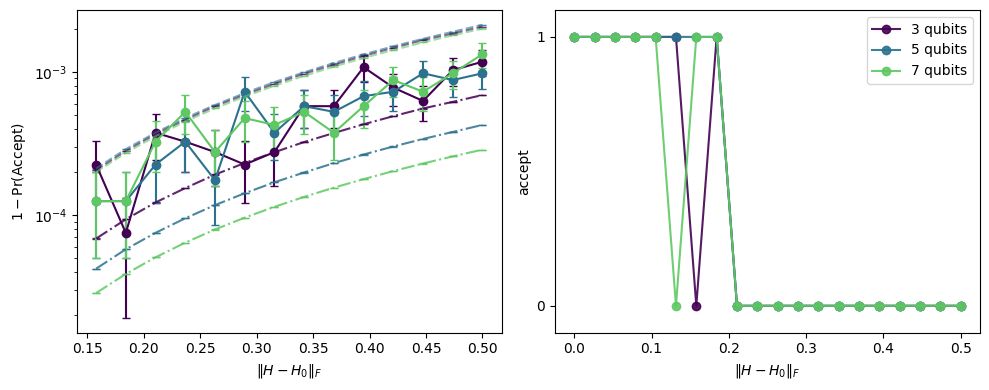

In [7]:
plotter = Plotter([exp3, exp5, exp7])
plotter.plot(log=True, xmin=0.14, z=1)